In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
xline = np.arange(0,1,0.01)
center=0.3
divisor= 0.01
share = 0.4
rlen = 100
spacing = rlen*3

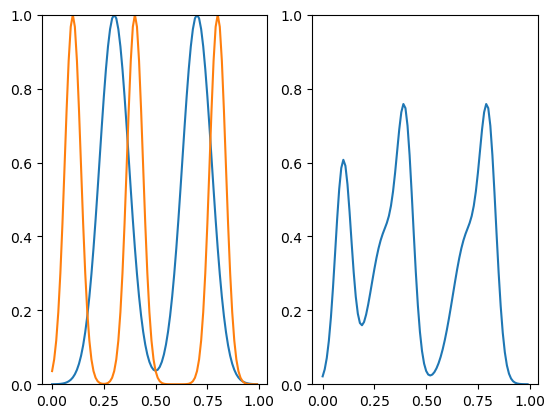

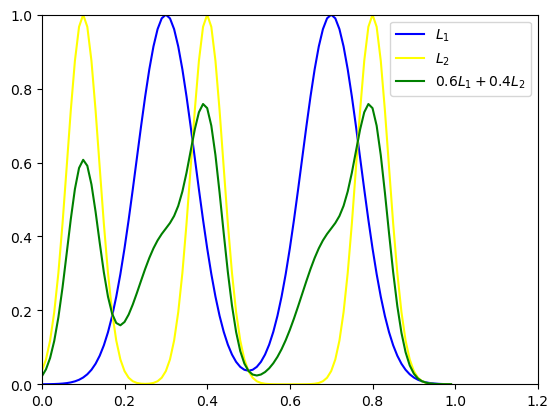

In [4]:

def get_gauss(center,divisor):
    return  np.exp(-(xline-center)**2/divisor)
obj1 = get_gauss(0.3,0.01)
obj1 += get_gauss(0.7,0.01)
obj2 = get_gauss(0.1, 0.003)
obj2 += get_gauss(0.4, 0.003)
obj2 += get_gauss(0.8, 0.003)


fig, axs = plt.subplots(1,2)
ax =axs[0] 
ax.plot(xline,obj1)
ax.plot(xline,obj2)
ax.set_ylim(0,1)
ax =axs[1] 
ax.set_ylim(0,1)
obj_mix = share*obj1+(1-share)*obj2
ax.plot(xline,obj_mix)

fig, ax = plt.subplots(1,1)
# ax =axs[0] 
ax.plot(xline,obj1,color="blue", label = "$L_1$")
ax.plot(xline,obj2, color="yellow", label= "$L_2$" )
ax.set_ylim(0,1,)
ax.set_xlim(0,1.2)
obj_mix = share*obj1+(1-share)*obj2
ax.plot(xline,obj_mix, color="green", label="$0.6L_1 + 0.4 L_2$")
ax.legend()

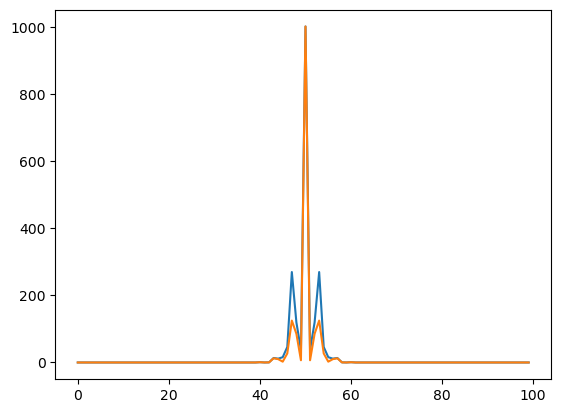

In [ ]:
ints_1  = np.abs(np.fft.fft(share*obj1))**2
ints_2 = np.abs(np.fft.fft((1-share)*obj2))**2
ints_12 = np.abs(np.fft.fft(share*obj1))*np.abs(np.fft.fft((1-share)*obj2))
ints_12_alt = np.abs(np.fft.fft(share*obj1)*np.fft.fft((1-share)*obj2))
# ints_1  = share*np.abs(np.fft.fft(obj1))**2
# ints_2 = (1-share)*np.abs(np.fft.fft(obj2))**2
# ints_12 = share*np.abs(np.fft.fft(obj1))*(1-share)*np.abs(np.fft.fft(obj2))
ints_comb = ints_1 + ints_2 + 2*ints_12
ints_mix = np.abs(np.fft.fft(obj_mix))**2
plt.figure()
plt.plot(np.fft.fftshift(ints_comb), label = "|I1|^2+ |I2|^2 + 2|I1||I2| ")
plt.plot(np.fft.fftshift(ints_mix), label = "|F(I)")
# plt.xlim(40,60)
# plt.plot(np.fft.fftshift(ints_comb-ints_mix))

In [6]:
combi = share*obj1+(1-share)*obj2
padding = rlen*len(combi)
mixed = np.pad(np.array([combi for ii in range(rlen)]).flatten(),padding)
ordered_list = np.array([obj1 if ii < share*rlen else obj2 for ii in range(rlen)])
mix = np.arange(rlen)
np.random.shuffle(mix)

ordered = np.pad((ordered_list).flatten(),padding)
unordered = np.pad((ordered_list[mix]).flatten(),padding)
np.random.shuffle(mix)
unordered2 = np.pad((ordered_list[mix]).flatten(),padding)
xdiff = xline[1]-xline[0]
xrange = np.arange(0,rlen*3, xdiff)

In [7]:
np.sum(mixed), np.sum(ordered), np.sum(unordered), 

(np.float64(3163.500943367604),
 np.float64(3163.5009433676037),
 np.float64(3163.500943367604))

(10.0, 12.0)

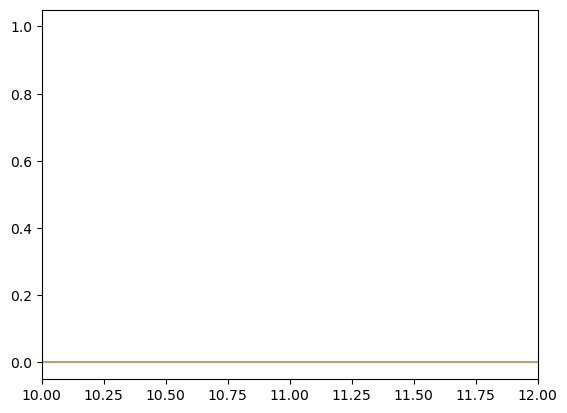

In [8]:
plt.plot(xrange, ordered, alpha=0.5)
plt.plot(xrange, unordered, alpha=0.5)
plt.xlim(10,12)

30000


ValueError: x and y must have same first dimension, but have shapes (100,) and (1000,)

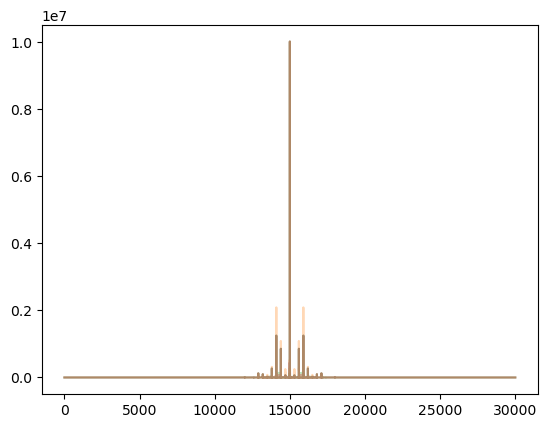

In [ ]:
print(len(unordered))
ints_mixed = np.abs(np.fft.fft(mixed))**2
ints_ordered = np.abs(np.fft.fft(ordered))**2
ints_unordered = np.abs(np.fft.fft(unordered))**2
ints_unordered2 = np.abs(np.fft.fft(unordered2))**2
plt.plot(np.fft.fftshift(ints_mixed), alpha= 0.3)
plt.plot(np.fft.fftshift(ints_ordered), alpha= 0.3)
plt.plot(np.fft.fftshift(ints_unordered), alpha= 0.3)
plt.plot(np.fft.fftshift(ints_unordered2), alpha= 0.3)
plt.plot(np.arange(3000)[::30],np.fft.fftshift(ints_mixed)[::spacing], marker = ".", linestyle="", color='r')
plt.xlim(1300,1700)
plt.ylim(0,5000)



(0.0, 5000.0)

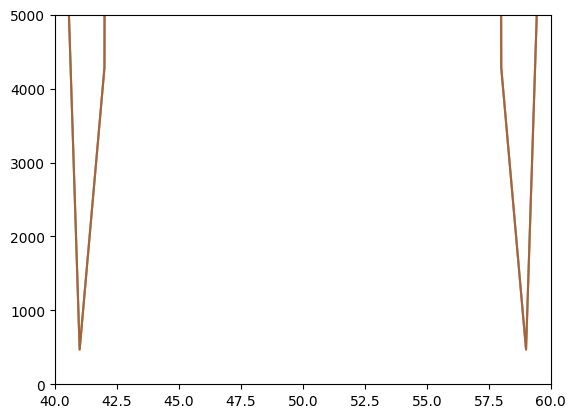

In [206]:
plt.plot(np.fft.fftshift(ints_mixed)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_ordered)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_unordered)[::spacing], alpha= 0.5)
plt.plot(np.fft.fftshift(ints_unordered2)[::spacing], alpha= 0.5)
plt.xlim(40,60)
plt.ylim(0,5000)

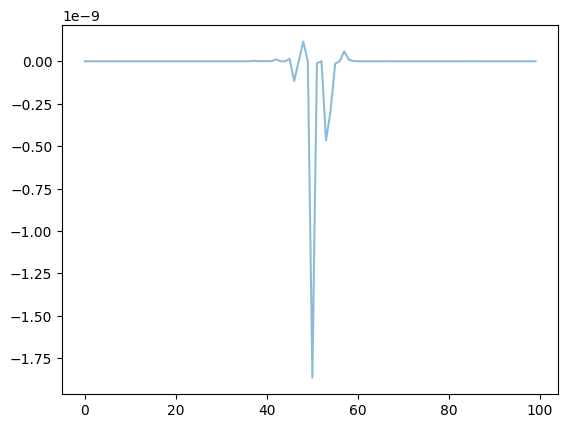

In [207]:
plt.plot(np.fft.fftshift(ints_mixed-ints_ordered)[::spacing], alpha= 0.5)


In [3]:
from skimage import data

In [4]:
data.horse()

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

((128, 128), 16384, (128, 128), 16384)

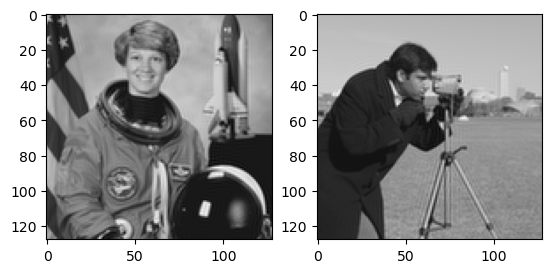

In [30]:
from skimage.color import rgb2gray
from scipy.signal import decimate
image1= rgb2gray(data.astronaut())
image1 = decimate(decimate(image1,4, axis=1), 4, axis=0)
image2 = decimate(decimate((data.camera()),4, axis=1),4,axis=0)
fig, axs = plt.subplots(1,2)
make_kwargs = lambda **x : x 
kwargs = make_kwargs(cmap="gray")
axs[0].imshow(image1, **kwargs)
axs[1].imshow(image2,**kwargs)
image1.shape, image1.size, image2.shape, image2.size

In [133]:
def make_grid(
    image1,
    image2,
    sidelen = 5,
    obj_size = 128,
    share = 0.2,
    ordered=True
):
    selection_range = np.arange(sidelen**2)
    slc = slice(0,int(sidelen**2*share))
    if ordered:
        select = selection_range[slc]
    else:
        select_shuffle = selection_range.copy()
        np.random.shuffle(select_shuffle)
        select_shuffle=select_shuffle[slc]
        select = select_shuffle
    base_struc = np.arange(sidelen**2).reshape(sidelen,sidelen)
    base = base_struc.repeat(obj_size,axis=0).repeat(obj_size,axis=1)
    masks = []
    for idx in range(sidelen**2):
        mask = base==idx
        masks.append(mask)

    for idx in range(sidelen**2):

        if idx in select:
            base[masks[idx]] = image1.flatten()
        else:
            base[masks[idx]] = image2.ravel()
    return base
def make_mixed(image1,image2,share,sidelen=5):
    mixed_image = share*image1+(1-share)*image2
    tiled_image = np.tile(mixed_image, (sidelen,sidelen))
    return tiled_image

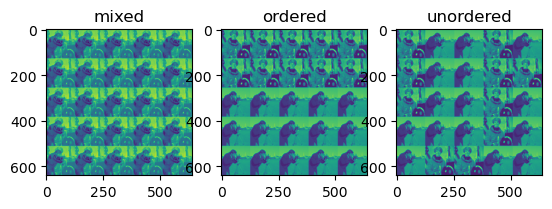

In [145]:
share=0.4
config = make_kwargs(
    share = 0.4,
    sidelen = 5
)
mixed = make_mixed(image1*255, image2, **config)
ordered = make_grid(image1*255,image2,**config)
unordered = make_grid(image1*255,image2,**config, ordered=False)
arrs = [mixed, ordered, unordered]
titles = ["mixed", "ordered", "unordered"]

fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr)


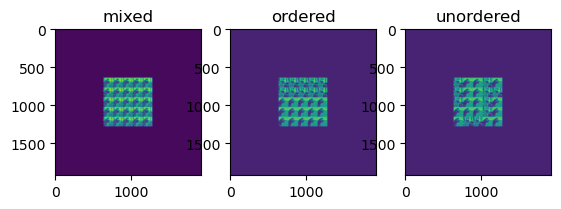

In [146]:
padlen = len(arr)

arrs_padded = [np.pad(arr,padlen) for arr in arrs]
fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs_padded):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr)


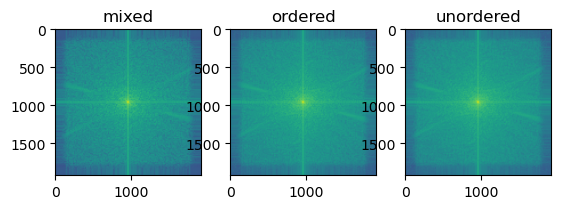

In [147]:
arrs_fft = [np.abs(np.fft.fft2(arr))**2 for arr in arrs_padded]
from matplotlib import colors 
fig, axs = plt.subplots(1,3)
norm =colors.LogNorm(1,np.max(arrs_fft))
for idx, arr in enumerate(arrs_fft):
    ax = axs[idx]
    ax.set_title(titles[idx])
    im = ax.imshow(np.fft.fftshift(arr),norm=norm)
    # plt.colorbar(im)



15


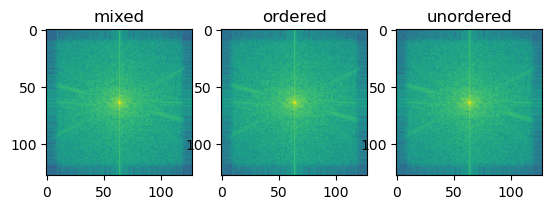

In [148]:
spacing = len(arrs_padded[0])//len(image1)
print(spacing)
arrs_bragg = [arr[::spacing,::spacing] for arr in arrs_fft]
fig, axs = plt.subplots(1,3)
for idx, arr in enumerate(arrs_bragg):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(np.fft.fftshift(arr),norm=norm)


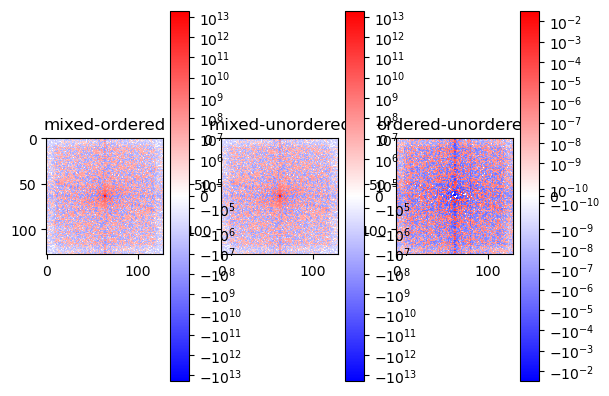

In [149]:
spacing = 2*config['sidelen']
arrs_diff = [
    arrs_bragg[0]-arrs_bragg[1],
    arrs_bragg[0]-arrs_bragg[2],
    arrs_bragg[1]-arrs_bragg[2],
]
fig, axs = plt.subplots(1,3)
title_diff = ["mixed-ordered", "mixed-unordered", "ordered-unordered"]
for idx, arr in enumerate(arrs_diff):
    ax = axs[idx]
    ax.set_title(title_diff[idx])
    vmax=np.max(np.abs(arr))
    snorm = colors.SymLogNorm(vmax/1e8, vmin=-vmax, vmax=vmax)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)
    plt.colorbar(im)




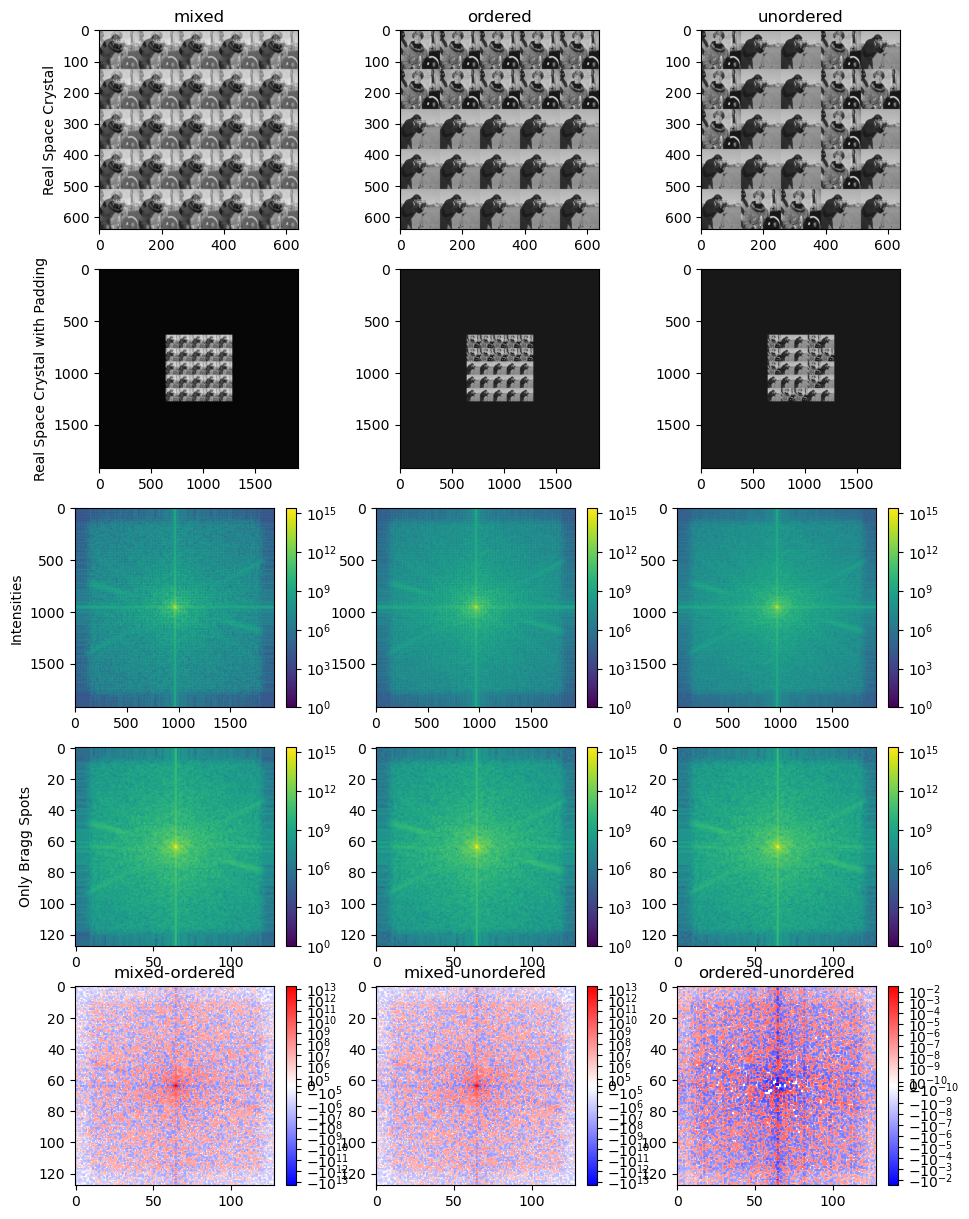

In [150]:

fig, axso = plt.subplots(5,3, figsize=(11,15), )
axs = axso[0]
axs[0].set_ylabel("Real Space Crystal")
for idx, arr in enumerate(arrs):
    ax = axs[idx]
    ax.set_title(titles[idx])
    ax.imshow(arr, cmap="grey")


axs = axso[1]
axs[0].set_ylabel("Real Space Crystal with Padding")
for idx, arr in enumerate(arrs_padded):
    ax = axs[idx]
    # ax.set_title(titles[idx])
    ax.imshow(arr, cmap="grey")


axs = axso[2]
axs[0].set_ylabel("Intensities")
for idx, arr in enumerate(arrs_fft):
    ax = axs[idx]
    # ax.set_title(titles[idx])
    im = ax.imshow(np.fft.fftshift(arr),norm=norm)
    plt.colorbar(im)
axs = axso[3]
axs[0].set_ylabel("Only Bragg Spots")
for idx, arr in enumerate(arrs_bragg):
    ax = axs[idx]
    im = ax.imshow(np.fft.fftshift(arr),norm=norm)
    plt.colorbar(im)
axs = axso[4]
for idx, arr in enumerate(arrs_diff):
    ax = axs[idx]
    vmax=np.max(np.abs(arr))
    ax.set_title(title_diff[idx])
    snorm = colors.SymLogNorm(vmax/1e8, vmin=-vmax, vmax=vmax)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)
    plt.colorbar(im)
    im = ax.imshow(np.fft.fftshift(arr),cmap="bwr", norm=snorm)